## Задача

Необходимо для любого документа или набора документов написать токенизатор, провести нормализацию полученного словаря (стемминг, лемматизация, синонимия, стоп-слова и т. п.) и построить простой анализатор тональности текста на естественном языке (на основе метода VADER-правил или наивного байесовоского классификатора). 

## Описание исходных данных

В качестве источника рассматриваемых документов выбран набор данных, посвященный анализу тональности текстовых публикаций в социальных сетях. 

Набор данных изначально разделен на обучающую и тестовую части и состоит из следующих атрибутов: 

textID – идентификационный номер публикации; 

text – текст публикации; 

sentiment – тональность публикации (negative, neutral или positive); 

Time of Tweet – время публикации (morning, noon, night) 

Age of User – возраст пользователя (0-20, 21-30, 31-45, 46-60, 60-70); 

Country – страна проживания пользователя; 

Population -2020 – популяция страны на 2020 год; 

Land Area (KmІ) – площадь страны; 

Density (P/KmІ) – плотность населения в стране. 

Для решения поставленной задачи из набора данных будут использованы только два атрибута: текст публикации и тональность публикации. Также для большей наглядности задача будет сведена к бинарной классификации тональности (позитивная и негативная). Для этого записи, соответствующие нейтральной тональности, будут исключены из анализа. 

In [10]:
#r "nuget: Microsoft.ML, 3.0.1"
#r "nuget: CsvHelper, 30.0.1"
#r "nuget: System.Text.Encoding.CodePages, 8.0.0"
#r "nuget: ScottPlot, 5.0.56"
#r "nuget: Microsoft.Data.Analysis, 0.22.2"


Installed Packages CsvHelper, 30.0.1 Microsoft.Data.Analysis, 0.22.2 Microsoft.ML, 3.0.1 ScottPlot, 5.0.56 System.Text.Encoding.CodePages, 8.0.0

In [11]:
using System;
using System.IO;
using System.Text;
using System.Text.RegularExpressions;
using System.Collections.Generic;
using System.Globalization;
using System.Linq;
using Microsoft.Data.Analysis;

using CsvHelper;
using CsvHelper.Configuration;

using ScottPlot;

Encoding.RegisterProvider(CodePagesEncodingProvider.Instance);


DataFrame LoadCsv(string path, string enc = "utf-8")
{
    using var fs = File.OpenRead(path);
    return DataFrame.LoadCsv(
        fs,
        separator: ',',
        header: true,
        encoding: Encoding.GetEncoding(enc),
        cultureInfo: CultureInfo.InvariantCulture
    );
}


In [12]:
using Microsoft.DotNet.Interactive.Formatting;


Formatter.Register(typeof(ScottPlot.Plot),
    (obj, writer) => writer.Write(((ScottPlot.Plot)obj).GetPngHtml(800, 450)),
    HtmlFormatter.MimeType);



Выполнение работы начинается с чтения и исследования входных данных, что продемонстрировано ниже. Из набора данных отбираются только те атрибуты, которые будут использованы для дальнейшего анализа, исключаются записи, соответствующие нейтральной тональности. Затем выполняется вывод размеров датасетов. Как видно, обучающий набор содержит 16363 записи, а тестовый – 3385. В конце блока продемонстрированы примеры публикаций и соответствующие метки тональности. 

In [13]:
var df_train = LoadCsv("../data/train.csv");
var df_test  = LoadCsv("../data/test.csv");

// Робастная фильтрация через перечисление строк (без зависимости от типов столбцов)
List<(string text, string sent)> FilterPairs(DataFrame df)
{
    var res = new List<(string, string)>();
    foreach (var r in df.Rows)
    {
        var t = r["text"]?.ToString() ?? string.Empty;
        var s = r["sentiment"]?.ToString() ?? string.Empty;
        if (string.IsNullOrWhiteSpace(t) || string.IsNullOrWhiteSpace(s)) continue;
        if (s == "neutral") continue;
        res.Add((t, s));
    }
    return res;
}
var trPairs = FilterPairs(df_train);
var tePairs = FilterPairs(df_test);
df_train = new DataFrame(new StringDataFrameColumn("text", trPairs.Select(p=>p.text)),
                        new StringDataFrameColumn("sentiment", trPairs.Select(p=>p.sent)));
df_test  = new DataFrame(new StringDataFrameColumn("text", tePairs.Select(p=>p.text)),
                        new StringDataFrameColumn("sentiment", tePairs.Select(p=>p.sent)));

// чутка итоговой диагностики
Console.WriteLine($"train shape: ({df_train.Rows.Count}, {df_train.Columns.Count})");
Console.WriteLine($"test  shape: ({df_test.Rows.Count}, {df_test.Columns.Count})");
//Console.WriteLine(df_train.Head(5));


train shape: (16363, 2)
test  shape: (2104, 2)


Для проверки датасета на сбалансированность была построена столбчатая диаграмма, представленная ниже. Из графика можно сделать вывод, что количество положительных и отрицательных публикаций различается незначительно. 


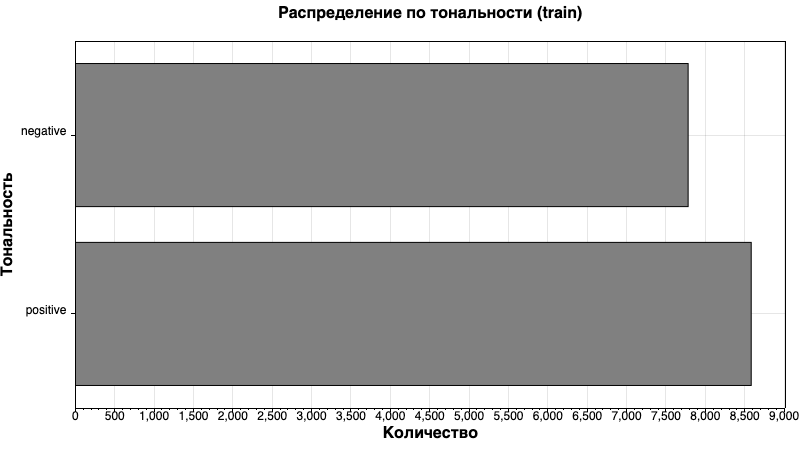

In [14]:
var dist = df_train.Rows
    .Select(r => (string)r["sentiment"])
    .GroupBy(s => s)
    .Select(g => new { Sentiment = g.Key, Count = g.Count() })
    .OrderByDescending(x => x.Count)
    .ToList();

var bars = dist.Select((d, i) => new ScottPlot.Bar { Position = i, Value = d.Count }).ToArray();
var plt = new ScottPlot.Plot();
var barPlot = plt.Add.Bars(bars);
barPlot.Horizontal = true;

var ticks = new ScottPlot.TickGenerators.NumericManual();
for (int i = 0; i < dist.Count; i++) ticks.AddMajor(i, dist[i].Sentiment);
plt.Axes.Left.TickGenerator = ticks;

plt.Title("Распределение по тональности (train)");
plt.Axes.Bottom.Label.Text = "Количество";
plt.Axes.Left.Label.Text = "Тональность";
plt.Axes.Margins(left: 0);

plt


Ниже приведена предобработка данных. Целевая переменная приводится к численному значению с помощью функции «encode_target_label». Текст публикаций подвергается нескольким этапам преобразований, которые сгруппированы в функции «preprocess_test»: 

приведение к нижнему регистру; 

удаление текста в квадратных скобках; 

удаление всех символов, кроме букв и цифр; 

удаление ссылок HTTP/HTTPS; 

удаление HTML-тегов; 

удаление пунктуации; 

удаление переходов на новую строку; 

удаление слов, содержащих цифры; 

токенизация; 

удаление стоп-слов; 

удаление слов, состоящих из одной буквы; 

лемматизация. 

In [15]:
// Небольшой список стоп-слов
var stopwords = new HashSet<string>(new []
{
    "a","an","and","are","as","at","be","by","for","from","has","he","in","is","it","its",
    "of","on","that","the","to","was","will","with","i","you","we","they","me","my","your",
    "our","their","him","her","us","them","this","these","those","am","are","is","was","were",
    "been","being","have","has","had","having","do","does","did","doing","would","could",
    "should","may","might","must","can","shall","ought","need","dare","used"
});

int EncodeTargetLabel(string label) =>
    label == "positive" ? 1 :
    label == "negative" ? -1 : 0;

string SimpleLemmatize(string w)
{
    if (w.EndsWith("ing") && w.Length > 5) return w[..^3];
    if (w.EndsWith("ed")  && w.Length > 4) return w[..^2];
    if (w.EndsWith("ly")  && w.Length > 4) return w[..^2];
    if (w.EndsWith("s")   && w.Length > 3) return w[..^1];
    return w;
}

List<string> PreprocessText(string text)
{
    text = text.ToLower();
    text = Regex.Replace(text, @"\[.*?\]", "");
    text = Regex.Replace(text, @"\W", " ");
    text = Regex.Replace(text, @"https?://\S+|www\.\S+", "");
    text = Regex.Replace(text, @"<.*?>+", "");
    text = Regex.Replace(text, @"[^\w\s]", "");
    text = Regex.Replace(text, @"\n", "");
    text = Regex.Replace(text, @"\w*\d\w*", "");

    var words = text.Split(' ', StringSplitOptions.RemoveEmptyEntries)
                    .Where(w => !stopwords.Contains(w))
                    .Where(w => w.Length > 1)
                    .Select(SimpleLemmatize)
                    .ToList();
    return words;
}


In [16]:
public class RowX
{
    public string Text { get; set; }
    public int Sentiment { get; set; }      // 1 / -1
    public List<string> Tokens { get; set; }
}

List<RowX> ToProcessed(DataFrame df) =>
    df.Rows
      .Select(r => new RowX {
          Text = (string)r["text"],
          Sentiment = EncodeTargetLabel((string)r["sentiment"]),
          Tokens = PreprocessText((string)r["text"])
      })
      .Where(r => r.Sentiment != 0 && r.Tokens.Count > 0)
      .ToList();

var trainX = ToProcessed(df_train);
var testX  = ToProcessed(df_test);

Console.WriteLine($"train after preprocess: {trainX.Count}");
Console.WriteLine($"test  after preprocess: {testX.Count}");

train after preprocess: 16359
test  after preprocess: 2104


In [17]:
Dictionary<string,bool> ToPresenceFeatures(List<string> tokens) =>
    tokens.Distinct().ToDictionary(w => w, _ => true);

var trainData = trainX
    .Select(r => (features: ToPresenceFeatures(r.Tokens), label: r.Sentiment, text: r.Text, tokens: r.Tokens))
    .ToList();

var testData = testX
    .Select(r => (features: ToPresenceFeatures(r.Tokens), label: r.Sentiment, text: r.Text, tokens: r.Tokens))
    .ToList();

In [18]:
public class NaiveBayesClassifier
{
    private readonly Dictionary<string, Dictionary<int,int>> wordCounts = new();
    private readonly Dictionary<int,int> classCounts = new();
    private int totalDocs = 0;

    public void Train(IEnumerable<(Dictionary<string,bool> features, int label)> data)
    {
        foreach (var (features, label) in data)
        {
            totalDocs++;
            if (!classCounts.ContainsKey(label)) classCounts[label] = 0;
            classCounts[label]++;

            foreach (var w in features.Keys)
            {
                if (!wordCounts.TryGetValue(w, out var perClass))
                {
                    perClass = new Dictionary<int,int>();
                    wordCounts[w] = perClass;
                }
                if (!perClass.ContainsKey(label)) perClass[label] = 0;
                perClass[label]++;
            }
        }
    }

    // лог-вероятности с Лапласом
    public int Predict(Dictionary<string,bool> features)
    {
        var scores = new Dictionary<int,double>();
        double V = Math.Max(1, wordCounts.Count);

        foreach (var cls in classCounts.Keys)
        {
            double score = Math.Log((double)classCounts[cls] / totalDocs);
            double classTotal = classCounts[cls];

            foreach (var w in features.Keys)
            {
                double count = (wordCounts.ContainsKey(w) && wordCounts[w].ContainsKey(cls))
                    ? wordCounts[w][cls] : 0.0;
                score += Math.Log((count + 1.0) / (classTotal + V));
            }
            scores[cls] = score;
        }
        return scores.OrderByDescending(kv => kv.Value).First().Key;
    }

    public Dictionary<int,double> PredictProba(Dictionary<string, bool> features)
    {
        var raw = new Dictionary<int,double>();
        double V = Math.Max(1, wordCounts.Count);

        foreach (var cls in classCounts.Keys)
        {
            double score = Math.Log((double)classCounts[cls] / totalDocs);
            double classTotal = classCounts[cls];
            foreach (var w in features.Keys)
            {
                double count = (wordCounts.ContainsKey(w) && wordCounts[w].ContainsKey(cls))
                    ? wordCounts[w][cls] : 0.0;
                score += Math.Log((count + 1.0) / (classTotal + V));
            }
            raw[cls] = score;
        }

        // softmax
        var m = raw.Values.Max();
        var exps = raw.ToDictionary(kv => kv.Key, kv => Math.Exp(kv.Value - m));
        var sum = exps.Values.Sum();
        return exps.ToDictionary(kv => kv.Key, kv => kv.Value / sum);
    }

    public void ShowMostInformativeFeatures(int topN = 10)
    {
        var feats = new List<(string word, double score, int cls)>();

        foreach (var (word, perClass) in wordCounts)
        {
            foreach (var (cls, cnt) in perClass)
            {
                double pWordGivenClass = (double)cnt / classCounts[cls];
                double pWord = (double)perClass.Values.Sum() / totalDocs;
                if (pWordGivenClass > 0 && pWord > 0)
                {
                    double score = pWordGivenClass * Math.Log(pWordGivenClass / pWord);
                    feats.Add((word, score, cls));
                }
            }
        }

        foreach (var f in feats.OrderByDescending(f => f.score).Take(topN))
        {
            var label = f.cls == 1 ? "positive" : "negative";
            Console.WriteLine($"{f.word,-20} = {label,-8} (score: {f.score:F2})");
        }
    }
}

var nb = new NaiveBayesClassifier();
nb.Train(trainData.Select(t => (t.features, t.label)));
Console.WriteLine("Модель обучена.");


Модель обучена.


После предобработки данных был построен наивный байесовский классификатор для анализа тональности текста, что продемонстрировано ниже. Полученная модель имеет точность 0.93 на обучающей выборке и 0.88 на тестовой, что говорит о его высокой прогнозной способности.

In [19]:
double Accuracy(IEnumerable<(Dictionary<string,bool> f, int y)> data, NaiveBayesClassifier model)
{
    int ok = 0, n = 0;
    foreach (var (f, y) in data)
    {
        var pred = model.Predict(f);
        if (pred == y) ok++;
        n++;
    }
    return n == 0 ? 0 : (double)ok / n;
}

Console.WriteLine($"Accuracy (train): {Accuracy(trainData.Select(t => (t.features, t.label)), nb):P4}");
Console.WriteLine($"Accuracy (test) : {Accuracy(testData .Select(t => (t.features, t.label)), nb):P4}");

Accuracy (train): 93.5387%
Accuracy (test) : 88.2129%


Ниже приведены 10 наиболее информативных признаков, которые учитывает классификатор при принятии решения. Как видно, все эти слова имеют яркую эмоциональную окраску. 

In [20]:
nb.ShowMostInformativeFeatures(10);

love                 = positive (score: 0.07)
happy                = positive (score: 0.06)
thank                = positive (score: 0.06)
good                 = positive (score: 0.06)
day                  = positive (score: 0.05)
not                  = negative (score: 0.04)
sad                  = negative (score: 0.04)
mother               = positive (score: 0.04)
mis                  = negative (score: 0.03)
great                = positive (score: 0.03)


Ниже можно наблюдать работу классификатора на тестовой выборке. 

In [21]:
for (int i = 0; i < Math.Min(7, testData.Count); i++)
{
    var sample = testData[i];
    var proba = nb.PredictProba(sample.features);
    var pred = proba.OrderByDescending(kv => kv.Value).First();

    Console.WriteLine($"original sentence: {sample.text}");
    Console.WriteLine($"transformed sentence: {string.Join(" ", sample.features.Keys)}");
    Console.WriteLine($"label: {sample.label}");
    Console.WriteLine($"model prediction: {(pred.Key == 1 ? "positive" : "negative")}");
}

original sentence: Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China:  (SH)  (BJ).
transformed sentence: shanghai also real excit precise skyscraper galore good tweep china sh bj
label: 1
model prediction: positive
original sentence: Recession hit Veronique Branquinho, she has to quit her company, such a shame!
transformed sentence: recession hit veronique branquinho she quit company such shame
label: -1
model prediction: negative
original sentence: happy bday!
transformed sentence: happy bday
label: 1
model prediction: positive
original sentence: http://twitpic.com/4w75p - I like it!!
transformed sentence: http twitpic com like
label: 1
model prediction: positive
original sentence: that`s great!! weee!! visitors!
transformed sentence: great weee visitor
label: 1
model prediction: positive
original sentence: I THINK EVERYONE HATES ME ON HERE   lol
transformed sentence: think everyone hate here lol
label: -1
model prediction: negative
original sent

Для выбранного набора документов был написан токенизатор, выполнена лемматизация, удалены стоп слова стоп-слова и другие элементы, которые не имеют семантической важности. На основе предобработанного текста построен анализатор тональности текста на естественном языке на основе наивного байесовоского классификатора.